In [ ]:
Test

In [ ]:
# 1. Spatial Join: Punkte behalten, Polygondaten anhängen
zwn_zh_dist_pop_gdf = gpd.sjoin(
    zwn_interp_gdf,
    zh_dist_pop_gdf,
    how="left",
    predicate="intersects"
)

# 2. Polygon-Geometrie anhand index_right zurückholen
zwn_zh_dist_pop_gdf["geometry_poly"] = zwn_zh_dist_pop_gdf["index_right"].map(
    zh_dist_pop_gdf.geometry
)

# 3. Polygon-Version als separates GeoDataFrame
zwn_zh_dist_pop_gdf_polygons = gpd.GeoDataFrame(
    zwn_zh_dist_pop_gdf.copy(),
    geometry="geometry_poly",
    crs=zwn_interp_gdf.crs
)

# 4. Kontrolle
print("CRS:", zwn_zh_dist_pop_gdf.crs)
display(zwn_zh_dist_pop_gdf.head(4))

print("Shape:", zwn_zh_dist_pop_gdf.shape)
print("Columns:", zwn_zh_dist_pop_gdf.columns.values)
display(zwn_zh_dist_pop_gdf.info())

# 5. Kontrolle: Punkt- und Polygongeometrie anzeigen
display(
    zwn_zh_dist_pop_gdf[
        ["geometry_zwn", "geometry_poly"]
    ].head()
)

# 6. Plot: Polygone + Punkte
ax = zwn_zh_dist_pop_gdf_polygons.plot(
    facecolor="none",
    edgecolor="black",
    figsize=(10, 10)
)

zwn_zh_dist_pop_gdf.plot(
    ax=ax,
    markersize=5,
    color="red"
)

# 2. Plotting the normalized density ratio
zwn_zh_dist_pop_gdf_polygons.plot(
    column="pop_density_2025",
    cmap="YlOrRd",
    figsize=(8, 5),
    legend=True,
    legend_kwds={"label": "Population Density (Inhabitants / Area)"},
    edgecolor="grey",
);

In [35]:
print(zwn_zh_dist_pop_gdf.geometry.name)  # sollte "geometry_zwn" ausgeben

geometry_zwn


In [ ]:
# Punkte mit mehrfachen Matches finden
duplicate_points = zwn_zh_dist_pop_gdf[
    zwn_zh_dist_pop_gdf.duplicated(
        subset="objectid_left",
        keep=False
    )
]


ax = zwn_zh_dist_pop_gdf.plot(
    figsize=(10, 8),
    color="white",
    edgecolor="black"
)



duplicate_points.plot(
    ax=ax,
    color="red",
    markersize=40
)

ax.set_title("Punkte ohne Polygon-Zuordnung")


In [ ]:
# 2. Polygon-Geometrie nachträglich dazu mergen via index_right
poly_geom = zh_dist_pop_gdf["geometry_poly"].rename("geometry_poly")

zwn_zh_dist_pop_gdf = zwn_zh_dist_pop_gdf.merge(
    poly_geom,
    left_on="index_right",
    right_index=True,
    how="left"
)

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 72928 entries, 0 to 72927
Data columns (total 55 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   objectid_left         72928 non-null  int64         
 1   service_request_id    72928 non-null  int64         
 2   requested_datetime    72928 non-null  datetime64[us]
 3   agency_sent_datetime  72928 non-null  datetime64[us]
 4   updated_datetime      72928 non-null  datetime64[us]
 5   e                     72928 non-null  int64         
 6   n                     72928 non-null  int64         
 7   service_code          72928 non-null  str           
 8   service_name          72928 non-null  str           
 9   status                72928 non-null  str           
 10  userid                72928 non-null  int64         
 11  title                 72926 non-null  str           
 12  detail                72926 non-null  str           
 13  media_url    

None

,qname,case_count
16,Langstrasse,6148
27,Sihlfeld,5257
3,Altstetten,4132
28,Unterstrass,3602
31,Wipkingen,3322
15,Höngg,3102
21,Oerlikon,2990
10,Hard,2872
33,Wollishofen,2843
5,Enge,2760


<Axes: xlabel='qname'>

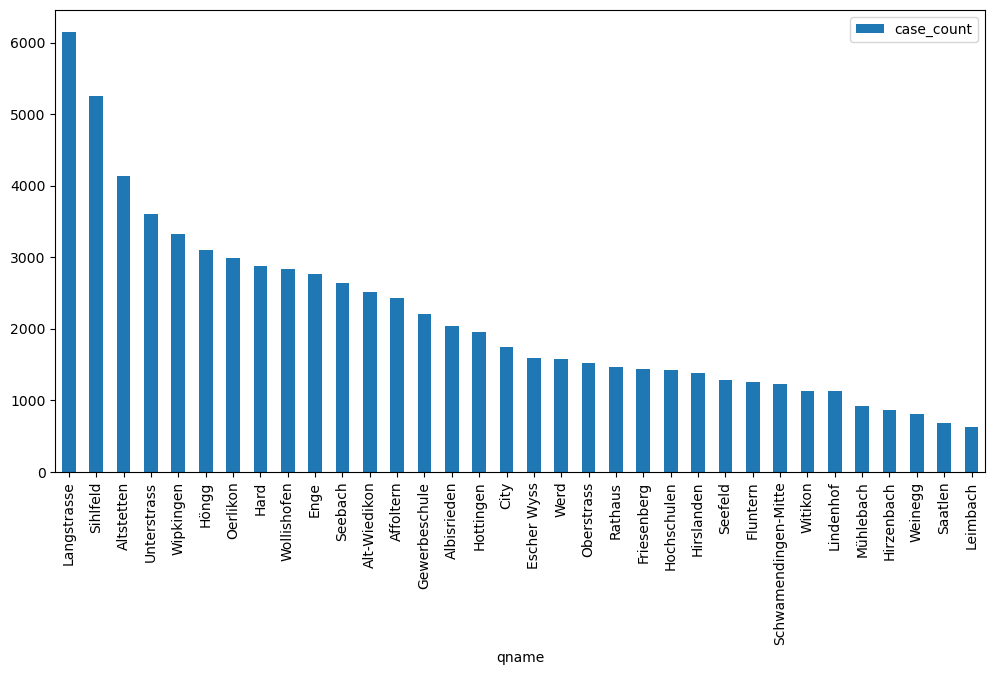

In [42]:
cases_per_district = (
    zwn_zh_dist_pop_gdf
    .groupby("qname")
    .size()
    .reset_index(name="case_count")
    .sort_values("case_count", ascending=False)
)
display(zwn_zh_dist_pop_gdf.info())
display(cases_per_district)

cases_per_district.plot(
    x="qname",
    y="case_count",
    kind="bar",
    figsize=(12,6)
)



In [ ]:
import matplotlib.pyplot as plt

# DataFrame
df = zh_dist_pop_gdf

# Nur gewünschte Jahre auswählen
year_cols = [
    "case_count_2014",
    "case_count_2017",
    "case_count_2021",
    "case_count_2025"
]

# DataFrame von wide -> long umformen
df_long = df.melt(
    id_vars="qname",
    value_vars=year_cols,
    var_name="Jahr",
    value_name="Fälle"
)

# Jahresnamen bereinigen
df_long["Jahr"] = df_long["Jahr"].str.replace("case_count_", "")

# Pivot-Tabelle erstellen
pivot_df = df_long.pivot(
    index="qname",
    columns="Jahr",
    values="Fälle"
)

# Bar Chart erstellen
pivot_df.plot(
    kind="bar",
    figsize=(16, 8)
)

plt.title("Fälle pro Jahr und Quartier")
plt.xlabel("Quartier")
plt.ylabel("Anzahl Fälle")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Jahr")

plt.tight_layout()
plt.show()